In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

In [2]:
# remove top and right spines for all plots in matplotlib params
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [3]:
import morethemes as mt

mt.set_theme("urban")

# https://coolors.co/1a4848-f7b000-f46036-c9f2c7-aceca1
plt.rcParams["axes.prop_cycle"] = plt.cycler(
    color=["#1a4848", "#f7b000", "#f46036", "#c9f2c7", "#aceca1"]
)

In [4]:
from pyfonts import load_google_font

bold_font = load_google_font("Urbanist", weight="bold")

## Discourse page views

In [5]:
import json
import os
import requests
import dotenv

url = "https://festim.discourse.group/admin/reports/consolidated_page_views.json"
dotenv.load_dotenv()
API_KEY = os.getenv("DISCOURSE_API_KEY")
assert API_KEY is not None, "DISCOURSE_API_KEY environment variable is not set"
end_date = datetime.now()
start_date = datetime(2022, 1, 1)

url += f"?start_date={start_date}&end_date={end_date}"

payload = {}
headers = {"Accept": "application/json", "Api-Key": API_KEY, "Api-Username": "remidm"}

response = requests.request("GET", url, headers=headers, data=payload)
response_data = json.loads(response.text)

In [6]:
# print(response_data)
data = pd.DataFrame(response_data["report"]["data"])

data.head()

,req,label,color,data
0,page_view_logged_in,Logged in users,#1EB8D1,"[{'x': '2023-11-23', 'y': 41}, {'x': '2023-11-..."
1,page_view_anon,Anonymous users,#9BC53D,"[{'x': '2023-11-23', 'y': 9}, {'x': '2023-11-2..."
2,page_view_crawler,Crawlers,#721D8D,"[{'x': '2023-11-24', 'y': 2}, {'x': '2023-11-2..."


In [7]:
data_filtered = {}

for row in data.itertuples():
    xs = [point['x'] for point in row.data]
    ys = [point['y'] for point in row.data]
    # convert to datetime
    xs = [datetime.strptime(x, "%Y-%m-%d") for x in xs]
    data_filtered[row.label] = (xs, ys)


In [8]:
# make a new dataframe with Day as the index and "logged in", "anonymous", "crawlers" as columns

all_days = set()
for label, (xs, ys) in data_filtered.items():
    all_days.update(xs)

all_days = sorted(all_days)

df = pd.DataFrame(columns=data_filtered.keys(), index=all_days)

for label, (xs, ys) in data_filtered.items():
    for x, y in zip(xs, ys):
        df.loc[x, label] = y

# set index name
df.index.name = "Day"

# convert index to column
df.reset_index(inplace=True)
df

,Day,Logged in users,Anonymous users,Crawlers
0,2023-11-23,41,9,NaN
1,2023-11-24,15,5,2
2,2023-11-26,1,18,NaN
3,2023-11-27,75,25,1
4,2023-11-28,92,41,1
...,...,...,...,...
874,2026-04-20,NaN,168,62
875,2026-04-21,NaN,88,76
876,2026-04-22,NaN,94,120
877,2026-04-23,2,104,162


In [9]:
# group per month based on the "Day" index (sum numeric columns only)
discourse_page_views_monthly = df.groupby(
    df["Day"].dt.to_period("M")
)[["Logged in users", "Anonymous users", "Crawlers"]].sum()

discourse_page_views_monthly.head()

,Logged in users,Anonymous users,Crawlers
Day,,,
2023-11,276,113,4
2023-12,474,124,41
2024-01,251,70,96
2024-02,242,92,58
2024-03,153,49,77


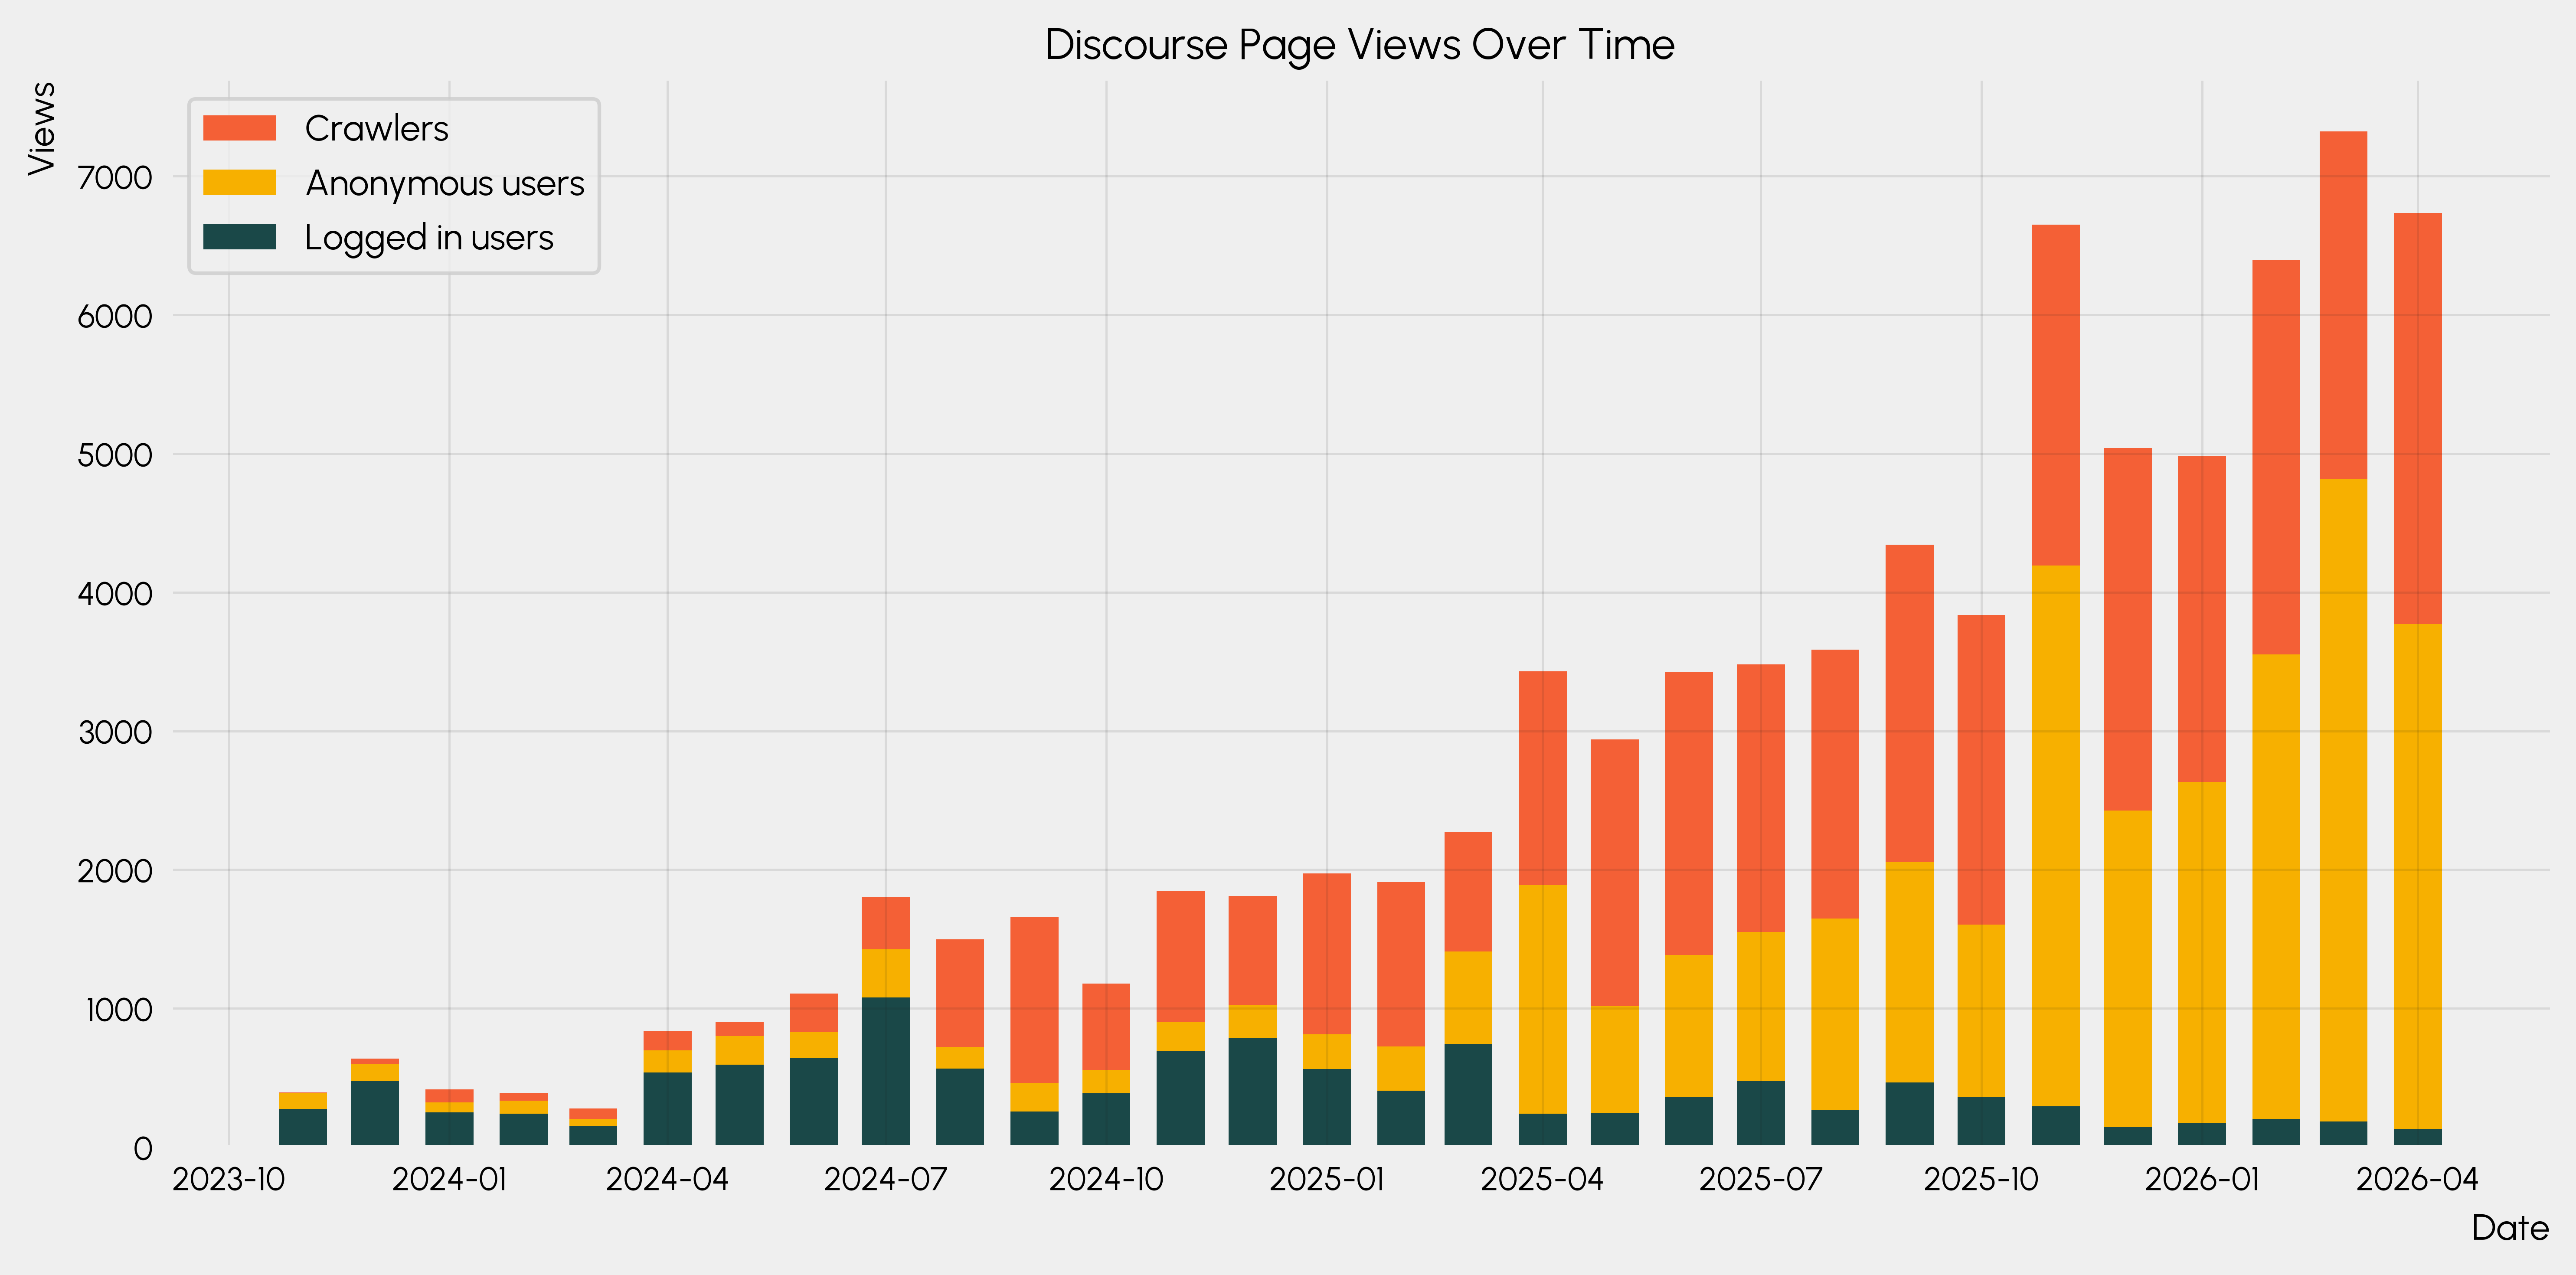

In [10]:
import matplotlib.pyplot as plt


def plot_page_views(width=20):
    x = (
        discourse_page_views_monthly.index.to_timestamp()
        if hasattr(discourse_page_views_monthly.index, "to_timestamp")
        else discourse_page_views_monthly.index
    )
    plt.bar(
        x,
        discourse_page_views_monthly["Logged in users"],
        label="Logged in users",
        width=width,
    )
    plt.bar(
        x,
        discourse_page_views_monthly["Anonymous users"],
        bottom=discourse_page_views_monthly["Logged in users"],
        label="Anonymous users",
        width=width,
    )
    plt.bar(
        x,
        discourse_page_views_monthly["Crawlers"],
        bottom=discourse_page_views_monthly["Logged in users"]
        + discourse_page_views_monthly["Anonymous users"],
        label="Crawlers",
        width=width,
    )


plt.figure(dpi=600, figsize=(10, 5))

# plot the data - convert PeriodIndex to timestamps for plotting
plot_page_views(width=20)
plt.title("Discourse Page Views Over Time")
plt.xlabel("Date")
plt.ylabel("Views")
plt.legend(reverse=True)
plt.tight_layout()
plt.show()

## Discourse signups

In [11]:
url = "https://festim.discourse.group/admin/reports/signups.json"
url += f"?chart_grouping=monthly&end_date={end_date}&start_date={start_date}"

payload = {}
headers = {"Accept": "application/json", "Api-Key": API_KEY, "Api-Username": "remidm"}

response = requests.request("GET", url, headers=headers, data=payload)
response
response_data = json.loads(response.text)
response_data


{'report': {'type': 'signups',
  'title': 'Signups',
  'xaxis': 'Day',
  'yaxis': 'Number of signups',
  'description': 'New account registrations for this period.',
  'description_link': None,
  'data': [{'x': '2023-11-23', 'y': 1},
   {'x': '2023-11-27', 'y': 3},
   {'x': '2023-12-04', 'y': 1},
   {'x': '2023-12-05', 'y': 1},
   {'x': '2023-12-13', 'y': 1},
   {'x': '2024-01-25', 'y': 1},
   {'x': '2024-04-06', 'y': 1},
   {'x': '2024-04-19', 'y': 1},
   {'x': '2024-04-26', 'y': 1},
   {'x': '2024-05-07', 'y': 1},
   {'x': '2024-05-16', 'y': 1},
   {'x': '2024-05-25', 'y': 1},
   {'x': '2024-06-27', 'y': 1},
   {'x': '2024-07-12', 'y': 1},
   {'x': '2024-07-22', 'y': 1},
   {'x': '2024-07-23', 'y': 1},
   {'x': '2024-07-24', 'y': 1},
   {'x': '2024-07-25', 'y': 1},
   {'x': '2024-08-01', 'y': 1},
   {'x': '2024-08-30', 'y': 1},
   {'x': '2024-09-23', 'y': 1},
   {'x': '2024-10-06', 'y': 1},
   {'x': '2024-10-07', 'y': 1},
   {'x': '2024-10-18', 'y': 1},
   {'x': '2024-11-01', 'y': 1}

In [12]:
report_data = response_data["report"]["data"]
signups_data_x = [datetime.strptime(point['x'], "%Y-%m-%d") for point in report_data]
signups_data_y = [point['y'] for point in report_data]

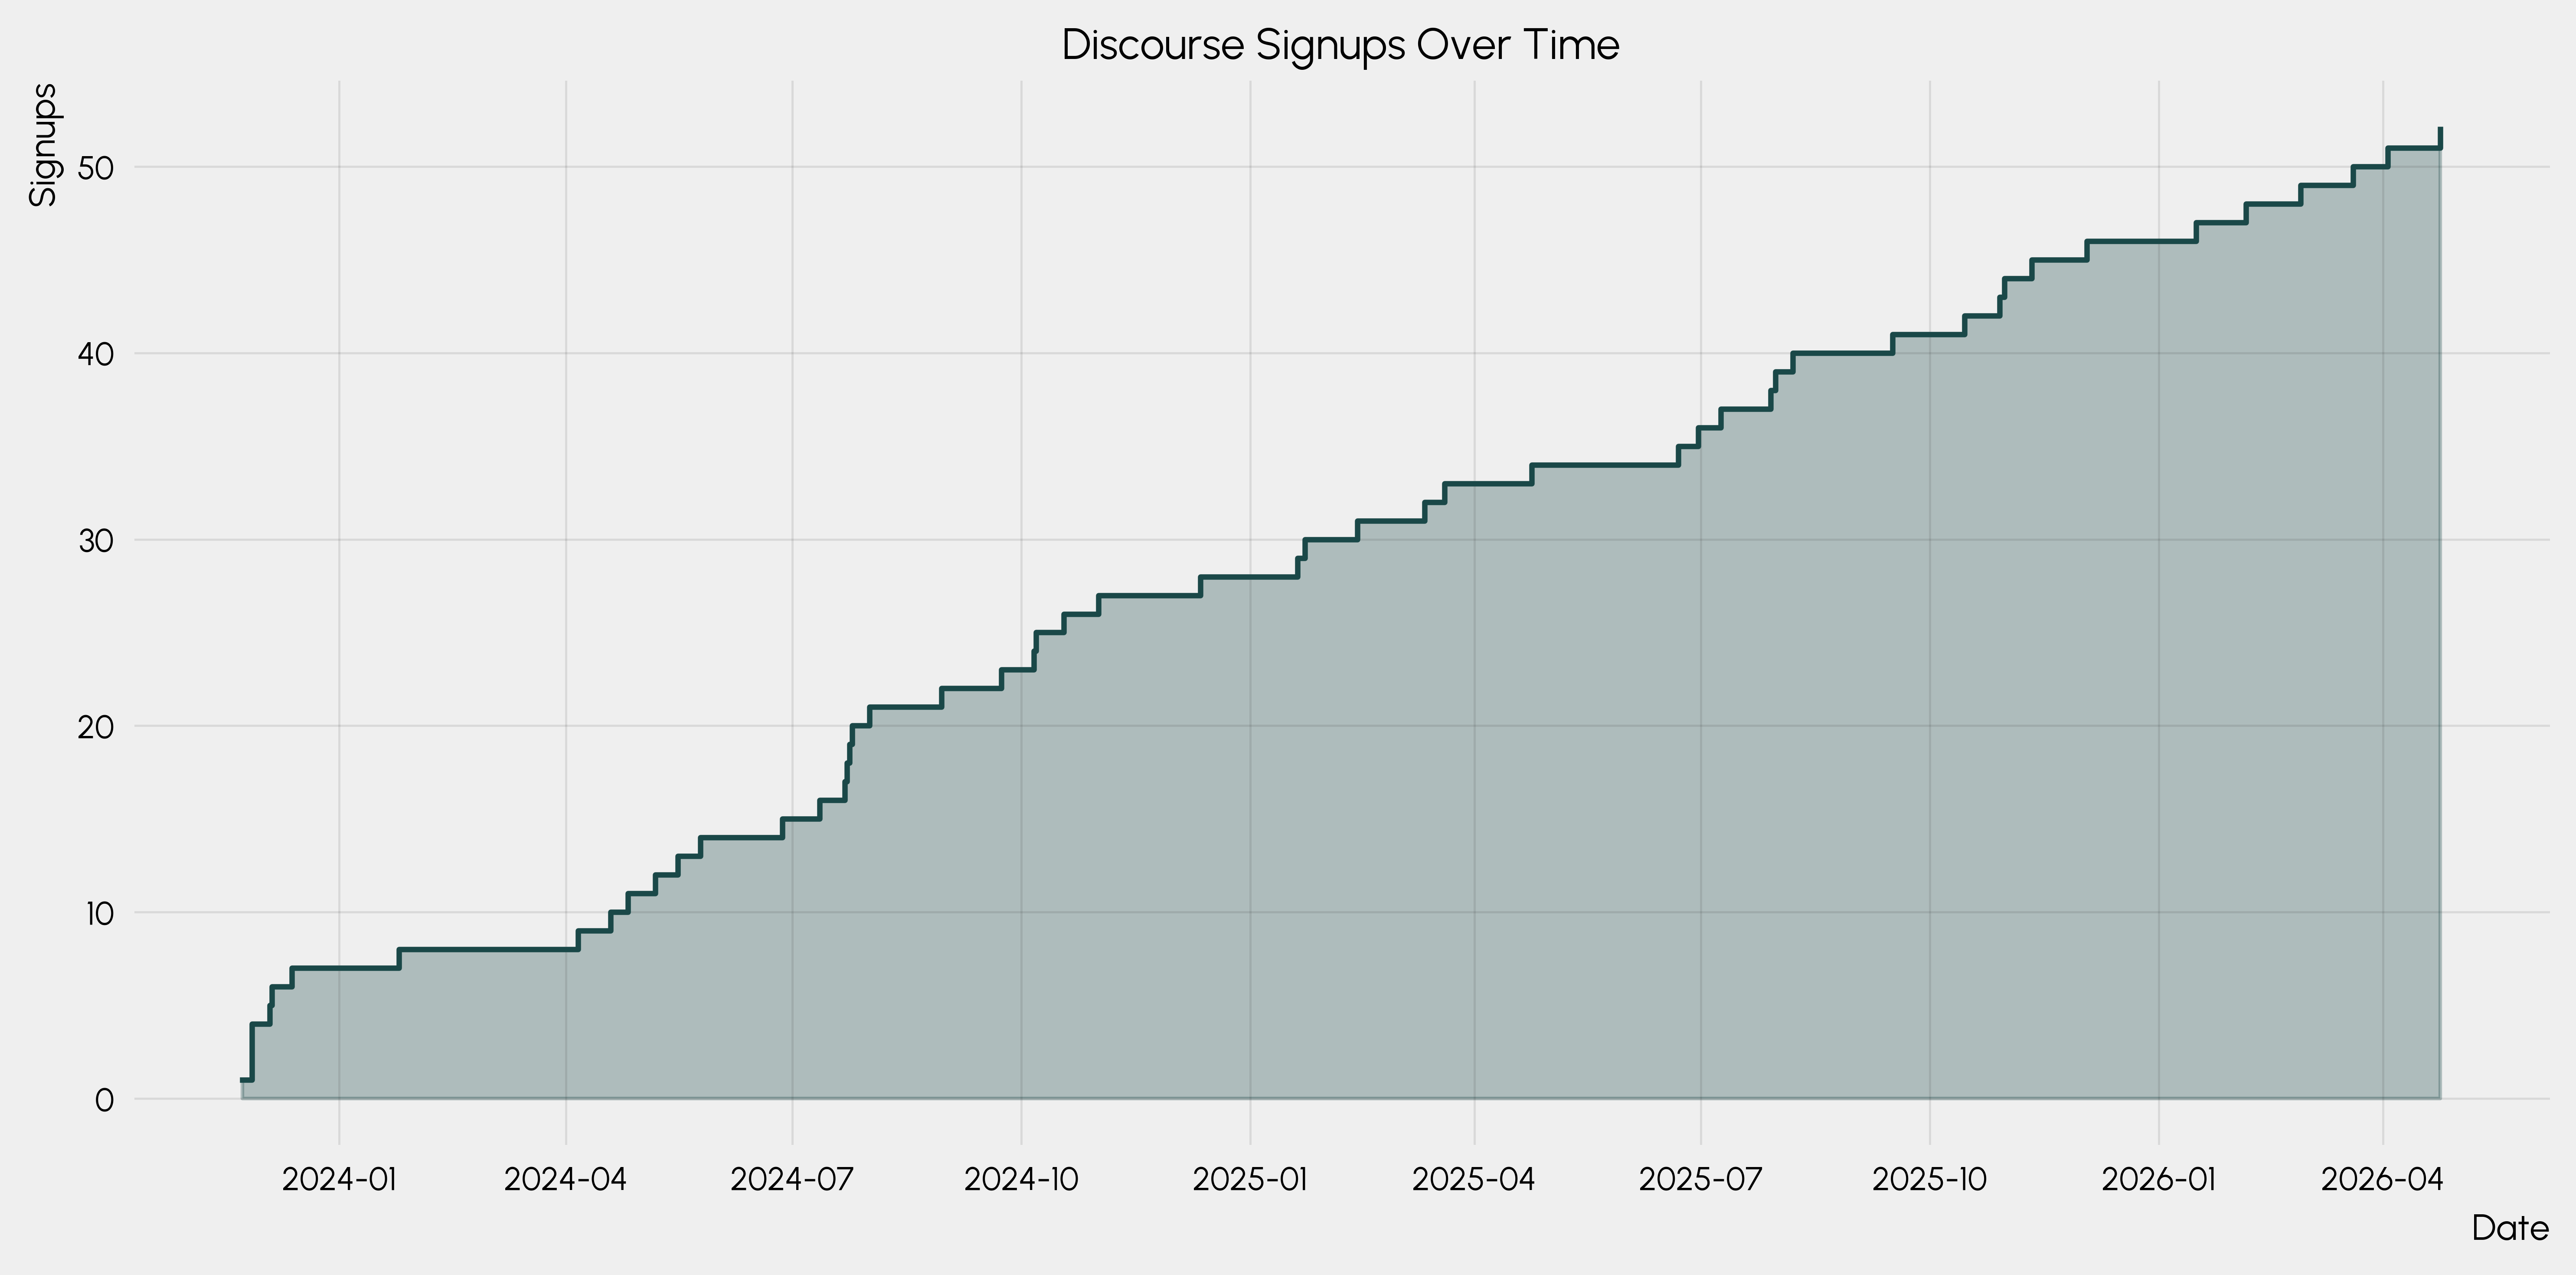

In [13]:
import numpy as np

def plot_signups(fill_between=True, **kwargs):
    cumulative_signups = np.cumsum(signups_data_y)
    (l,) = plt.step(signups_data_x, cumulative_signups, where="post", **kwargs)
    if fill_between:
        plt.fill_between(signups_data_x, cumulative_signups, alpha=0.3, color=l.get_color(), step="post")

    return signups_data_x, cumulative_signups


plt.figure(dpi=600, figsize=(10, 5))

# plot the data - convert PeriodIndex to timestamps for plotting
plot_signups()
plt.title("Discourse Signups Over Time")
plt.xlabel("Date")
plt.ylabel("Signups")
plt.tight_layout()
plt.show()

## Star history

In [14]:
import requests

OWNER = "festim-dev"
REPO = "festim"


url = f"https://api.github.com/repos/{OWNER}/{REPO}/stargazers"
headers = {
    "Accept": "application/vnd.github.v3.star+json",
    # "Authorization": f"Bearer {TOKEN}",  # uncomment for higher rate limits
}
page = 1
all_stars = []
while True:
    url = f"https://api.github.com/repos/{OWNER}/{REPO}/stargazers"
    # NOTE there seems to be a limit of 100 per page, so we need to paginate through the results
    response = requests.get(
        url, headers=headers, params={"per_page": 100, "page": page}
    )
    data = response.json()

    if not data:
        break

    all_stars.extend(data)
    page += 1

In [15]:
# Each item now has "starred_at" and "user"
for star in all_stars:
    print(star["starred_at"], star["user"]["login"])

2021-12-13T20:33:01Z mougenj
2022-07-27T12:22:30Z stephen-dixon
2022-07-27T12:34:14Z shimwell
2022-07-27T12:42:03Z jhillairet
2022-07-27T13:30:40Z BilelJegham
2022-07-27T13:44:39Z tianyikillua
2022-07-27T18:36:04Z giovanni-mariano
2022-08-08T22:30:23Z tkoyama010
2022-08-12T11:52:39Z StephDlpmtn
2022-08-12T23:59:54Z pshriwise
2022-08-19T06:58:50Z tengfeideng
2022-08-29T13:12:55Z ehodille
2022-09-13T15:36:45Z MKastek
2022-09-29T07:30:47Z liliangillier
2022-10-23T08:21:00Z husni-zuhdi
2022-12-13T22:51:24Z jlogan-cfs
2022-12-14T16:29:29Z lcarasik
2023-01-10T00:15:43Z george-poole
2023-06-21T06:59:44Z XuesenYang
2023-07-09T12:14:02Z FranFani
2023-07-09T12:31:20Z DinushaJ
2023-07-09T14:12:28Z FuerstT
2023-07-09T15:41:32Z PXC998
2023-07-09T15:41:38Z jehbice
2023-07-09T15:41:46Z niamh-holland
2023-07-09T15:41:47Z steven-van-boxel
2023-07-09T15:41:49Z zhengs-cn
2023-07-09T15:41:51Z AMPechero
2023-07-09T15:41:57Z odvorak89
2023-07-09T15:42:15Z LukeFisherUKAEA
2023-07-09T15:42:18Z AKI-1997
2023-0

In [16]:
from numpy import cumsum
from datetime import datetime

# Convert "starred_at" to datetime and sort
star_dates = sorted(
    [datetime.strptime(star["starred_at"], "%Y-%m-%dT%H:%M:%SZ") for star in all_stars]
)
# Create a cumulative count of stars over time
cumulative_stars = cumsum([1] * len(star_dates))

Text(0, 1, 'Cumulative Stars')

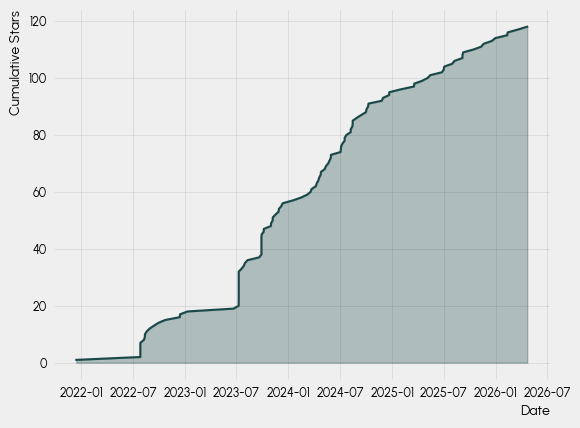

In [17]:
import matplotlib.pyplot as plt


def plot_star_history(fillbetween=True):
    (l,) = plt.plot(star_dates, cumulative_stars)
    if fillbetween:
        plt.fill_between(star_dates, cumulative_stars, alpha=0.3, color=l.get_color())

    return l


plot_star_history()
plt.xlabel("Date")
plt.ylabel("Cumulative Stars")

## User workshops

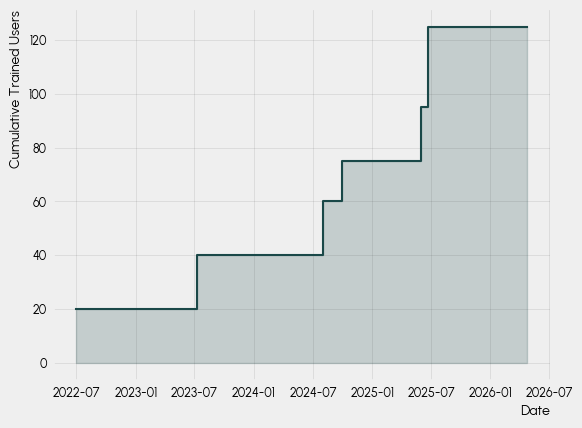

In [18]:
import numpy as np

workshop_data = [
    {
        "name": "SOFE 2025",
        "date": datetime(2025, 6, 23),
        "attendees": 30,
    },
    {
        "name": "SOFE 2023",
        "date": datetime(2023, 7, 9),
        "attendees": 20,
    },
    {
        "name": "CEA LMJ",
        "date": datetime(2025, 6, 1),
        "attendees": 20,
    },
    {
        "name": "UKAEA",
        "date": datetime(2024, 8, 1),
        "attendees": 20,
    },
    {
        "name": "IPP Garching",
        "date": datetime(2024, 9, 30),
        "attendees": 15,
    },
    {
        "name": "Kyoto Fusioneering",
        "date": datetime(2022, 7, 1),
        "attendees": 20,
    },
]


def plot_trained_users_over_time(workshop_data, fill_between=True):
    _workshop_data = sorted(workshop_data, key=lambda x: x["date"])

    cumulative_trained_users = np.cumsum(
        [workshop["attendees"] for workshop in _workshop_data]
    )
    workshop_dates = [workshop["date"] for workshop in _workshop_data]

    # add today with the latest number
    workshop_dates.append(datetime.today())
    cumulative_trained_users = np.append(
        cumulative_trained_users, cumulative_trained_users[-1]
    )

    (l,) = plt.step(workshop_dates, cumulative_trained_users, where="post")
    if fill_between:
        plt.fill_between(
            workshop_dates,
            cumulative_trained_users,
            step="post",
            alpha=0.2,
            color=l.get_color(),
        )

    return workshop_dates, cumulative_trained_users


plt.figure()
plot_trained_users_over_time(workshop_data)
plt.xlabel("Date")
plt.ylabel("Cumulative Trained Users")
plt.show()


## Google analytics

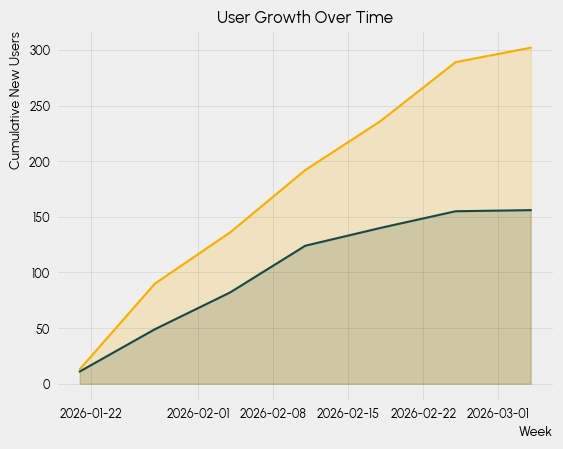

In [19]:
# TODO try and use the python GA API https://medium.com/@tmmylo1021/extract-google-analytics-data-with-python-221626ed8975

# data_ga = pandas.read_csv("View_user_engagement_and_retention_overview.csv")

# data_ga


def plot_new_users_over_time_tutorials(fill_between=True, **kwargs):
    start_date_ga = datetime(2025, 12, 3)
    end_date_ga = datetime(2026, 3, 2)
    nth_week = [7, 8, 9, 10, 11, 12, 13]
    new_users = [11, 38, 33, 42, 16, 15, 1]

    new_users_cumulative = np.cumsum(new_users)

    # convert nth_week to datetime for plotting
    nth_week_dates = [start_date_ga + pd.Timedelta(weeks=n) for n in nth_week]
    (l,) = plt.plot(nth_week_dates, new_users_cumulative, **kwargs)
    if fill_between:
        plt.fill_between(
            nth_week_dates, new_users_cumulative, alpha=0.2, color=l.get_color()
        )
    return nth_week_dates, new_users_cumulative


def plot_new_users_over_time_docs(fill_between=True, **kwargs):
    start_date_ga = datetime(2025, 12, 3)
    end_date_ga = datetime(2026, 3, 2)

    nth_week = [7, 8, 9, 10, 11, 12, 13]
    new_users = [13, 77, 46, 56, 44, 53, 13]

    new_users_cumulative = np.cumsum(new_users)

    # convert nth_week to datetime for plotting
    nth_week_dates = [start_date_ga + pd.Timedelta(weeks=n) for n in nth_week]
    (l,) = plt.plot(nth_week_dates, new_users_cumulative, **kwargs)
    if fill_between:
        plt.fill_between(
            nth_week_dates, new_users_cumulative, alpha=0.2, color=l.get_color()
        )
    return nth_week_dates, new_users_cumulative


plot_new_users_over_time_tutorials()
plot_new_users_over_time_docs()
plt.xlabel("Week")
plt.ylabel("Cumulative New Users")
plt.title("User Growth Over Time")
plt.show()


## GitHub contributors (main)

In [20]:
from get_contributors import fetch_contributor_stats

timeline = fetch_contributor_stats(OWNER, REPO)


def plot_contributor_stats(fill_between=True, **kwargs):
    dates = [entry["date"] for entry in timeline]
    cumulative_contributors = [entry["cumulative_contributors"] for entry in timeline]
    (l,) = plt.step(dates, cumulative_contributors, where="post", **kwargs)
    if fill_between:
        plt.fill_between(
            dates,
            cumulative_contributors,
            step="post",
            alpha=0.2,
            color=l.get_color(),
        )
    return dates, cumulative_contributors


plot_contributor_stats()

plt.tight_layout()
plt.show()

GITHUB_TOKEN not found in environment variables.
⏳ Stats being computed, retrying in 3s... (attempt 1/10)
⏳ Stats being computed, retrying in 3s... (attempt 2/10)


KeyboardInterrupt: 

## Main figure

In [21]:
def extrapolate_data(xs, ys, future_date):
    # Fit a linear model to the existing data
    x = np.array([(date - xs[0]).days for date in xs])
    y = ys
    coeffs = np.polyfit(x, y, 1)  # Linear fit
    slope, intercept = coeffs

    # Extrapolate to the future date
    future_x = (future_date - xs[0]).days
    extrapolated_y = slope * future_x + intercept

    return extrapolated_y

In [22]:
def add_milestone(
    date, label, text_kwargs=None, line_kwargs=None, xytext=(0, 10), arrow=False
):
    if text_kwargs is None:
        text_kwargs = {}
    if line_kwargs is None:
        line_kwargs = {}
    l = plt.axvline(x=date, **line_kwargs)
    # text above the line
    if arrow:
        arrowprops = dict(arrowstyle="-", color=l.get_color(), linestyle="dashed")
    else:
        arrowprops = None
    plt.annotate(
        label,
        xy=(date, 1),
        xytext=xytext,
        textcoords="offset points",
        ha="center",
        color=l.get_color(),
        arrowprops=arrowprops,
        **text_kwargs,
    )
    return l


def add_period(start, end, label, text_kwargs=None, line_kwargs=None):
    if text_kwargs is None:
        text_kwargs = {}
    if line_kwargs is None:
        line_kwargs = {}
    plt.axvspan(start, end, alpha=0.3, **line_kwargs)
    plt.annotate(
        label,
        xy=((start + (end - start) / 2), 0.5),
        va="center",
        ha="center",
        **text_kwargs,
    )

def add_datapoint_annotation(x, y, text=True, xytext=(0, 10), **kwargs):
    plt.scatter(x, y, **kwargs)
    if text:
        plt.annotate(
            f"{y}",
            xy=(x, y),
            xytext=xytext,
            textcoords="offset points",
            ha="center",
            fontsize=12,
            alpha=kwargs.get("alpha", 1.0),
            color=kwargs.get("color", "C0")
        )


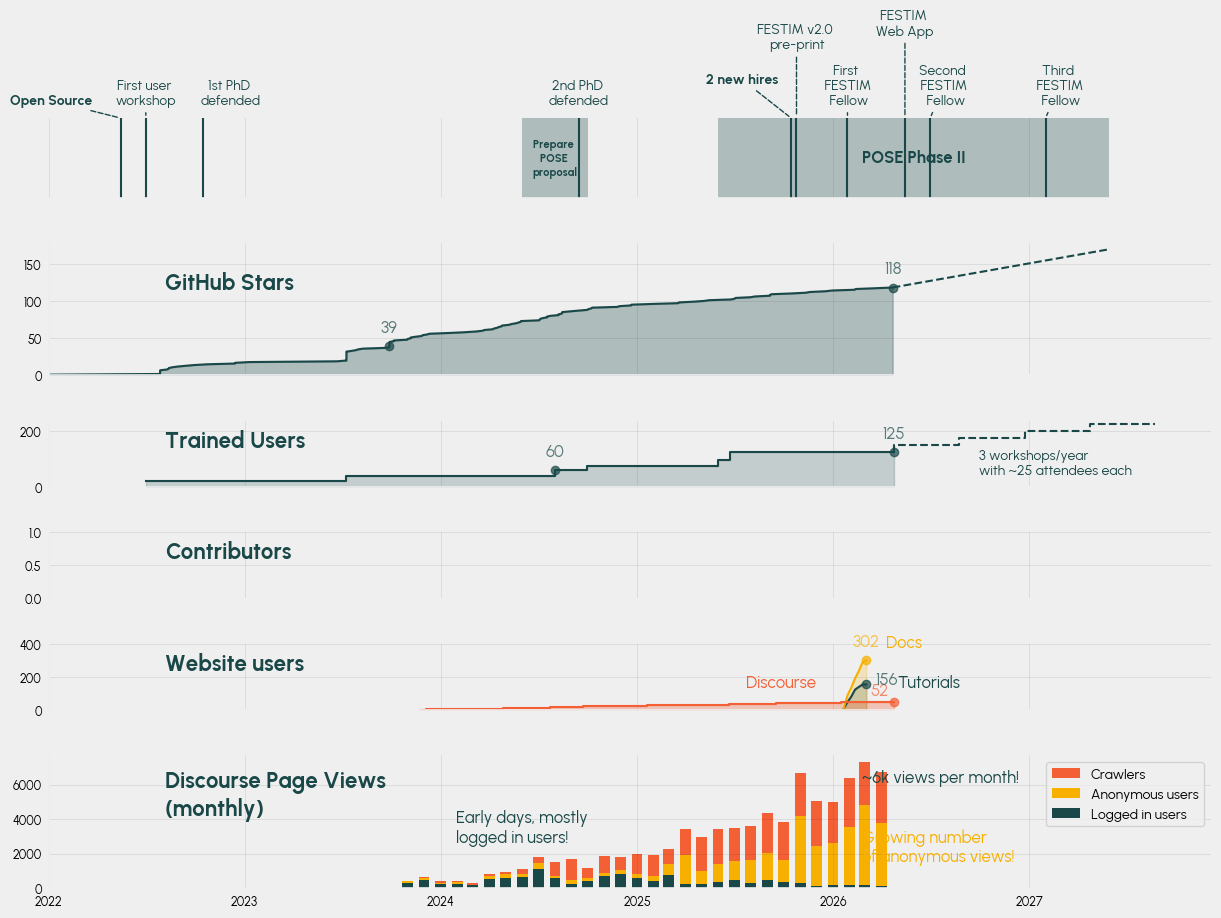

In [23]:
phase_ii_start = datetime(2025, 6, 1)
phase_ii_end = datetime(2027, 5, 31)

title_coords = (0.1, 0.7)
title_colour = "C0"

fig, axs = plt.subplots(
    nrows=6,
    ncols=1,
    sharex=True,
    figsize=(15, 10),
    height_ratios=[0.6, 1, 0.5, 0.5, 0.5, 1],
)

plt.subplots_adjust(hspace=0.5)


plt.sca(axs[1])
l = plot_star_history()
extrapolate_stars_nb = extrapolate_data(star_dates, cumulative_stars, phase_ii_end)
plt.plot(
    [star_dates[-1], phase_ii_end],
    [cumulative_stars[-1], extrapolate_stars_nb],
    linestyle="--",
    color=l.get_color(),
)
add_datapoint_annotation(
    star_dates[-80], cumulative_stars[-80], color=l.get_color(), alpha=0.7
)
add_datapoint_annotation(
    star_dates[-1], cumulative_stars[-1], color=l.get_color(), alpha=0.7
)

plt.annotate(
    "GitHub Stars",
    xy=title_coords,
    xycoords="axes fraction",
    va="center",
    fontsize=16,
    color=title_colour,
    font=bold_font,
)

plt.ylim(bottom=0)


plt.sca(axs[2])
workshop_dates, cumulative_trained_users = plot_trained_users_over_time(workshop_data)

# 3 workshops a year with ~25 ppls each
nb_workshops_per_year = 3
ppl_per_workshop = 25
new_workshop_dates = [
    workshop_dates[-1] + pd.Timedelta(days=365 * i / nb_workshops_per_year)
    for i in range(1, 5)
]
new_cumulative_trained_users = (
    cumulative_trained_users[-1] + np.arange(1, 5) * ppl_per_workshop
)

# add last point
new_workshop_dates.insert(0, workshop_dates[-1])
new_cumulative_trained_users = np.insert(
    new_cumulative_trained_users, 0, cumulative_trained_users[-1]
)
plt.step(
    new_workshop_dates,
    new_cumulative_trained_users,
    linestyle="--",
    color=l.get_color(),
)

for index in [-1, -5]:  # annotate the last and the 5th last point
    add_datapoint_annotation(
        workshop_dates[index],
        cumulative_trained_users[index],
        color=l.get_color(),
        alpha=0.7,
    )

plt.annotate(
    "Trained Users",
    xy=title_coords,
    xycoords="axes fraction",
    va="center",
    fontsize=16,
    color=title_colour,
    font=bold_font,
)

plt.annotate(
    "3 workshops/year \nwith ~25 attendees each",
    xy=(0.8, 0.2),
    xycoords="axes fraction",
    ha="left",
    fontsize=10,
    color="C0",
)

plt.ylim(bottom=0)

plt.sca(axs[3])

# contributor_dates, cumulative_contributors = plot_contributor_stats()

# for index in [-1, -60]:  # annotate the last and the 5th last point
#     add_datapoint_annotation(
#         contributor_dates[index],
#         cumulative_contributors[index],
#         color=l.get_color(),
#         alpha=0.7,
#     )

plt.annotate(
    "Contributors",
    xy=title_coords,
    xycoords="axes fraction",
    va="center",
    fontsize=16,
    color=title_colour,
    font=bold_font,
)

plt.ylim(bottom=0)

plt.sca(axs[4])
dates_users_tuto, users_tuto_cumul = plot_new_users_over_time_tutorials(label="Tutorials")
dates_users_docs, users_docs_cumul = plot_new_users_over_time_docs(label="Docs")
dates_signups, signups_cumul = plot_signups(label="Discourse signups")

plt.annotate(
    "Website users",
    xy=title_coords,
    xycoords="axes fraction",
    va="center",
    fontsize=16,
    color=title_colour,
    font=bold_font,
)
plt.annotate(
    f"Discourse",
    xy=(0.6, 0.35),
    xycoords="axes fraction",
    ha="left",
    fontsize=12,
    color="C2",
)
plt.annotate(
    f"Docs",
    xy=(0.72, 0.95),
    xycoords="axes fraction",
    ha="left",
    fontsize=12,
    color="C1",
)
plt.annotate(
    f"Tutorials",
    xy=(0.73, 0.35),
    xycoords="axes fraction",
    ha="left",
    fontsize=12,
    color="C0",
)
for dates, cumul, color, xytext in [
    (dates_signups, signups_cumul, "C2", (-10, 5)),
    (dates_users_docs, users_docs_cumul, "C1", (0, 10)),
    (dates_users_tuto, users_tuto_cumul, "C0", (15, 0)),
]:
    index = -1  # annotate the last point
    add_datapoint_annotation(
            dates[index],
            cumul[index],
            color=color,
            alpha=0.7,
            xytext=xytext,
        )


# plt.legend(reverse=True)
plt.ylim(bottom=0, top=400)

plt.sca(axs[5])
plot_page_views(width=20)
plt.annotate(
    "Discourse Page Views\n(monthly)",
    xy=title_coords,
    xycoords="axes fraction",
    va="center",
    fontsize=16,
    color=title_colour,
    font=bold_font,
)

plt.annotate(
    "Early days, mostly\nlogged in users!",
    xy=(0.35, 0.35),
    xycoords="axes fraction",
    ha="left",
    fontsize=12,
    color="C0",
)
plt.annotate(
    "Growing number \nof anonymous views!",
    xy=(0.7, 0.2),
    xycoords="axes fraction",
    ha="left",
    fontsize=12,
    color="C1",
)
plt.annotate(
    "~6k views per month!",
    xy=(0.7, 0.8),
    xycoords="axes fraction",
    ha="left",
    fontsize=12,
    color="C0",
)
plt.legend(reverse=True)
plt.ylim(bottom=0)

plt.sca(axs[0])

add_milestone(
    datetime(2022, 5, 15),
    "Open Source",
    xytext=(-50, 10),
    arrow=True,
    text_kwargs={"font": bold_font},
)
add_milestone(datetime(2022, 10, 15), "1st PhD \ndefended", xytext=(20, 10))
add_milestone(datetime(2024, 9, 15), "2nd PhD \ndefended", xytext=(0, 10))
add_milestone(workshop_dates[0], "First user \nworkshop", xytext=(0, 10), arrow=True)
# add_milestone(ga_users_dates[0], "Google \nAnalytics", xytext=(-25, -25), arrow=True)
add_milestone(datetime(2026, 5, 15), "FESTIM \nWeb App", xytext=(0, 60), arrow=True)
add_milestone(datetime(2026, 1, 28), "First \n FESTIM \n Fellow", arrow=True)
add_milestone(
    datetime(2026, 7, 1), "Second \n FESTIM \n Fellow", xytext=(10, 10), arrow=True
)
add_milestone(
    datetime(2027, 2, 1), "Third \n FESTIM \n Fellow", xytext=(10, 10), arrow=True
)


add_period(
    datetime(2024, 6, 1),
    datetime(2024, 10, 1),
    label="Prepare \nPOSE \nproposal",
    text_kwargs={"color": "C0", "font": bold_font, "fontsize": 8},
)

add_period(
    phase_ii_start,
    phase_ii_end,
    label="POSE Phase II",
    text_kwargs={"color": "C0", "font": bold_font, "fontsize": 12},
)

add_milestone(
    datetime(2025, 10, 25), "FESTIM v2.0 \npre-print", xytext=(0, 50), arrow=True
)
add_milestone(
    datetime(2025, 10, 15),
    "2 new hires",
    xytext=(-35, +25),
    arrow=True,
    text_kwargs={"font": bold_font},
)

plt.gca().tick_params(axis='x', which='major', labelsize=20)

plt.gca().get_yaxis().set_visible(False)
plt.gca().spines["left"].set_visible(False)

plt.xlim(left=datetime(2022, 1, 1))
plt.savefig("timeline.svg")
plt.show()

## Demographics

In [49]:
# data manipulation
import numpy as np
import pandas as pd
import geopandas as gpd

# visualization
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.font_manager import FontProperties
# from highlight_text import fig_text, ax_text
from matplotlib.patches import FancyArrowPatch

# geospatial manipulation
import cartopy.crs as ccrs
import cartopy.feature as cfeature
# import geoplot
# import geoplot.crs as gcrs

In [50]:
proj = ccrs.Mercator()

url = "https://raw.githubusercontent.com/holtzy/The-Python-Graph-Gallery/master/static/data/all_world.geojson"
world = gpd.read_file(url)
world = world[~world['name'].isin(["Antarctica", "Greenland"])]
world = world.to_crs(proj.proj4_init)
world.head()

,name,geometry
0,Fiji,"MULTIPOLYGON (((20037508.343 -1800679.237, 200..."
1,Tanzania,"POLYGON ((3774143.866 -105050.44, 3792946.708 ..."
2,W. Sahara,"POLYGON ((-964649.018 3185897.152, -964597.245..."
3,Canada,"MULTIPOLYGON (((-13674486.249 6242596, -136894..."
4,United States of America,"MULTIPOLYGON (((-13674486.249 6242596, -133583..."


Fetches the data on fusion organisations from fusionenergybase.com

In [51]:
import requests
import pandas as pd

def get_fusion_machine_developers():
    page = 1

    while True:
        url = f"https://www.fusionenergybase.com/api/v1/organizations/?page={page}&tag=fusion-machine-developers&sort=display_name"
        response = requests.get(url)
        data = response.json()
        if data["next"] is None:
            break
        yield data
        page += 1

def get_research_organizations():
    page = 1

    while True:
        url = f"https://www.fusionenergybase.com/api/v1/organizations/?page={page}&tag=research-organizations&sort=display_name"
        response = requests.get(url)
        data = response.json()
        if data["next"] is None:
            break
        yield data
        page += 1


# function to aggregate data from all pages into a dataframe
def aggregate_data(organization_generator):
    all_data = []
    for data in organization_generator:
        all_data.extend(data["results"])
    return pd.DataFrame(all_data)

fusion_machine_developers_data = aggregate_data(get_fusion_machine_developers())
research_organizations_data = aggregate_data(get_research_organizations())


In [52]:
fusion_machine_developers_data.head()

,id,display_name,official_name,acronym_name,slug,logo,website_url,jobs_url,city,region,...,organization_tags,total_funding,description,is_affiliate,is_approved,self_description,contact_email,updated_at,country_flag_emoji,country_flag_url
0,574,Acceleron Fusion,NaN,NaN,acceleron-fusion,https://feb3.s3.amazonaws.com/organizations/Ac...,https://www.acceleron.energy/,NaN,Cambridge,Massachusetts,...,"[{'slug': 'fusion-machine-developer', 'display...",39370112,Acceleron Fusion is pursuing a novel approach ...,False,True,NaN,NaN,2025-12-17T15:56:44.539452+00:00,🇺🇸,https://flagsapi.com/US/flat/64.png
1,774,Anubal Fusion,NaN,NaN,anubal-fusion,https://feb3.s3.amazonaws.com/organizations/an...,https://anubalfusion.com/,NaN,Gurgoan,Huryana,...,"[{'slug': 'fusion-machine-developer', 'display...",0,Anubal Fusion is a fusion energy startup found...,False,True,NaN,NaN,2025-10-29T14:12:02.138403+00:00,🇮🇳,https://flagsapi.com/IN/flat/64.png
2,194,Avalanche,"Avalanche, Inc.",NaN,avalanche,https://feb3.s3.amazonaws.com/organizations/lo...,https://http://www.avalanchefusion.com,https://www.avalanchefusion.com/careers/open-p...,Tukwila,Washington,...,"[{'slug': 'fusion-machine-developer', 'display...",98900000,Avalanche is developing a fusion concept calle...,False,True,NaN,NaN,2026-03-16T22:14:03.690416+00:00,🇺🇸,https://flagsapi.com/US/flat/64.png
3,482,Blue Laser Fusion,NaN,NaN,blue-laser-fusion,https://feb3.s3.amazonaws.com/organizations/Bl...,https://bluelaserfusion.com,https://bluelaserfusion.com/careers/,Goleta,California,...,"[{'slug': 'fusion-machine-developer', 'display...",37500000,Blue Laser Fusion is pursuing a laser inertial...,False,True,NaN,NaN,2025-10-16T20:20:14.615275+00:00,🇺🇸,https://flagsapi.com/US/flat/64.png
4,891,Cambridge Heavy Industries,NaN,NaN,cambridge-heavy-industries,NaN,https://cambridgeheavy.xyz,NaN,NaN,NaN,...,"[{'slug': 'fusion-machine-developer', 'display...",0,NaN,False,True,NaN,NaN,2026-03-19T14:21:46.031902+00:00,NaN,NaN


In [53]:
# use cached geocoding results if available
# for the locations that are not in the cache, use geocode

if os.path.exists("locations_fusion_developers.geojson"):
    locations_fusion_developers_from_cache = gpd.read_file("locations_fusion_developers.geojson")

if os.path.exists("locations_orgs.geojson"):
    locations_orgs = gpd.read_file("locations_orgs.geojson")


locations_fusion_developers_not_found = set(fusion_machine_developers_data["city"]) - set(locations_fusion_developers_from_cache["city"])


if locations_fusion_developers_not_found:
    print(f"Geocoding {len(locations_fusion_developers_not_found)} cities for fusion machine developers...")
    locations_fusion_developers_new = gpd.tools.geocode(list(locations_fusion_developers_not_found))
    locations_fusion_developers = pd.concat([locations_fusion_developers_from_cache, locations_fusion_developers_new], ignore_index=True)
else:
     locations_fusion_developers = locations_fusion_developers_from_cache

locations_orgs_not_found = set(research_organizations_data["city"]) - set(locations_orgs["city"])
if locations_orgs_not_found:
    print(f"Geocoding {len(locations_orgs_not_found)} cities for research organizations...")
    locations_orgs_new = gpd.tools.geocode(list(locations_orgs_not_found))
    locations_orgs = pd.concat([locations_orgs, locations_orgs_new], ignore_index=True)
else:
    locations_orgs = locations_orgs

# print("Getting locations for fusion machine developers...")
# locations_fusion_developers = gpd.tools.geocode(fusion_machine_developers_data["city"])
# print("Getting locations for research organizations...")
# locations_orgs = gpd.tools.geocode(research_organizations_data["city"])


In [54]:
locations_fusion_developers["city"] = fusion_machine_developers_data["city"]
locations_orgs["city"] = research_organizations_data["city"]

# cache the geocoding results to avoid hitting the API repeatedly during development
locations_fusion_developers.to_file("locations_fusion_developers.geojson", driver="GeoJSON")
locations_orgs.to_file("locations_orgs.geojson", driver="GeoJSON")

In [55]:
print(locations_fusion_developers.columns)

Index(['address', 'city', 'geometry'], dtype='str')


This fetches the data from Google Analytics using the python API. It requires that Google Cloud CLI is installed and that the user is logged in.

In [ ]:
from google.analytics.data_v1beta import BetaAnalyticsDataClient
from google.analytics.data_v1beta.types import (
    DateRange,
    Dimension,
    Metric,
    RunReportRequest,
)

start_date_ga = datetime(2026, 3, 15)

def users_city(property_id="YOUR-GA4-PROPERTY-ID"):
    """Runs a simple report on a Google Analytics 4 property."""
    # TODO(developer): Uncomment this variable and replace with your
    #  Google Analytics 4 property ID before running the sample.
    # property_id = "YOUR-GA4-PROPERTY-ID"

    # Using a default constructor instructs the client to use the credentials
    # specified in GOOGLE_APPLICATION_CREDENTIALS environment variable.
    client = BetaAnalyticsDataClient()

    request = RunReportRequest(
        property=f"properties/{property_id}",
        dimensions=[Dimension(name="city")],
        metrics=[Metric(name="activeUsers")],
        date_ranges=[DateRange(start_date=start_date_ga.strftime("%Y-%m-%d"), end_date="today")],
    )
    response = client.run_report(request)

    print("Report result:")
    for row in response.rows:
        print(row.dimension_values[0].value, row.metric_values[0].value)
    
    return response

def users_world(property_id="YOUR-GA4-PROPERTY-ID"):
    """Runs a simple report on a Google Analytics 4 property."""
    # TODO(developer): Uncomment this variable and replace with your
    #  Google Analytics 4 property ID before running the sample.
    # property_id = "YOUR-GA4-PROPERTY-ID"

    # Using a default constructor instructs the client to use the credentials
    # specified in GOOGLE_APPLICATION_CREDENTIALS environment variable.
    client = BetaAnalyticsDataClient()

    request = RunReportRequest(
        property=f"properties/{property_id}",
        dimensions=[Dimension(name="country")],
        metrics=[Metric(name="activeUsers"), Metric(name="newUsers")],
        date_ranges=[DateRange(start_date=start_date_ga.strftime("%Y-%m-%d"), end_date="today")],
    )
    response = client.run_report(request)

    print("Report result:")
    for row in response.rows:
        print(row.dimension_values[0].value, row.metric_values[0].value, row.metric_values[1].value)

    return response


def engagement_time_per_active_user(property_id="YOUR-GA4-PROPERTY-ID"):
    """Runs a simple report on a Google Analytics 4 property."""
    # TODO(developer): Uncomment this variable and replace with your
    #  Google Analytics 4 property ID before running the sample.
    # property_id = "YOUR-GA4-PROPERTY-ID"

    # Using a default constructor instructs the client to use the credentials
    # specified in GOOGLE_APPLICATION_CREDENTIALS environment variable.
    client = BetaAnalyticsDataClient()

    request = RunReportRequest(
        property=f"properties/{property_id}",
        dimensions=[Dimension(name="city")],
        metrics=[Metric(name="userEngagementDuration"), Metric(name="activeUsers")],
        date_ranges=[DateRange(start_date=start_date_ga.strftime("%Y-%m-%d"), end_date="today")],
    )
    response = client.run_report(request)

    print("Report result:")
    for row in response.rows:
        print(row.dimension_values[0].value, row.metric_values[0].value, row.metric_values[1].value)

    return response

In [57]:
FESTIM_DOCS_ID = "521295665"
FESTIM_TUTO_ID = "521287230"
response = users_city(FESTIM_DOCS_ID)

Report result:
(not set) 189
Phoenix 60
Des Moines 58
Boydton 48
Moses Lake 48
San Jose 44
Cheyenne 43
Chicago 36
San Antonio 32
Cambridge 24
London 21
Paris 15
Manchester 13
Shanghai 13
Brussels 11
Munich 11
Cardiff 10
Frankfurt am Main 9
Milan 8
Oxford 8
Council Bluffs 7
Guangzhou 7
Hong Kong 7
Madrid 7
Ashburn 6
Singapore 6
Bristol 5
Chengdu 5
Garching 5
Karlsruhe 5
Leoben 5
Los Angeles 5
Madison 5
Saclay 5
Turin 5
Aspen 4
Boston 4
Didcot 4
Ho Chi Minh City 4
Kyoto 4
New York 4
Shizuoka 4
Tehran 4
Tsukuba 4
Vienna 4
 3
Amsterdam 3
Berlin 3
Bogota 3
Bryan 3
Everett 3
Hangzhou 3
Minneapolis 3
Moscow 3
Princeton 3
Saint Petersburg 3
Sendai 3
Shenzhen 3
Somerville 3
Stockholm 3
Toki 3
Villeurbanne 3
Abingdon 2
Amman 2
Bangor 2
Bath 2
Bayingolin Mongol Autonomous Prefecture 2
Beijing 2
Boardman 2
Burlington 2
Chennai 2
College Station 2
Coutances 2
Dallas 2
Delhi 2
Dublin 2
Fitchburg 2
Gradignan 2
Gunsan-si 2
Islamabad 2
Julich 2
Kearny 2
Knoxville 2
Manila 2
Marseille 2
Mumbai 2
Naples 

In [58]:
df_users = pd.DataFrame(
    {
        "city": [row.dimension_values[0].value for row in response.rows],
        "activeUsers": [int(row.metric_values[0].value) for row in response.rows],
    }
)

In [59]:
# remove line (not set) from df
df_users = df_users[df_users['city'] != '(not set)']
df_users.head()

,city,activeUsers
1,Phoenix,60
2,Des Moines,58
3,Boydton,48
4,Moses Lake,48
5,San Jose,44


In [60]:
# try and find from cache first, if not found, geocode the city
if os.path.exists("locations_users.geojson"):
    locations_users_from_cache = gpd.read_file("locations_users.geojson")
    locations_users_not_found = set(df_users["city"]) - set(locations_users_from_cache["city"])
    if locations_users_not_found:
        print(f"Geocoding {len(locations_users_not_found)} cities for users...")
        locations_users_new = gpd.tools.geocode(list(locations_users_not_found))
        locations_users = pd.concat([locations_users_from_cache, locations_users_new], ignore_index=True)
    else:
        locations_users = locations_users_from_cache
else:
    print("Geocoding cities for users...")
    locations_users = gpd.tools.geocode(df_users["city"])

In [61]:
# cache locations_users
locations_users["city"] = df_users["city"]
locations_users.to_file("locations_users.geojson", driver="GeoJSON")

In [62]:
response_countries = users_world(FESTIM_DOCS_ID)

Report result:
United States 489 486
China 136 131
United Kingdom 106 105
France 47 46
Germany 46 45
Japan 32 32
Italy 25 22
India 20 18
Belgium 11 11
Spain 11 11
Russia 10 9
Austria 9 9
Singapore 9 8
Hong Kong 8 7
Vietnam 7 6
Netherlands 6 6
(not set) 5 5
South Korea 5 5
Iran 4 4
Pakistan 4 4
Sweden 4 3
Brazil 3 1
Colombia 3 3
Iraq 3 2
Norway 3 3
Peru 3 3
Philippines 3 1
Saudi Arabia 3 3
Argentina 2 1
Bangladesh 2 2
Canada 2 2
Denmark 2 2
Ecuador 2 0
Ireland 2 2
Jordan 2 2
Oman 2 2
Poland 2 2
Serbia 2 2
Switzerland 2 2
Taiwan 2 1
Tunisia 2 2
United Arab Emirates 2 2
Albania 1 1
Czechia 1 1
Finland 1 1
Indonesia 1 1
Kenya 1 1
Luxembourg 1 1
Malaysia 1 1
Morocco 1 1
Nepal 1 1
New Zealand 1 1
Nigeria 1 1
Panama 1 1
Qatar 1 1
Romania 1 1
Venezuela 1 1


In [63]:
import matplotlib.gridspec as gridspec

def plot_europe(ax, s, locations):
    """Plot Europe zoom in the inset axes"""
    # Set the extent to focus on Europe
    # [-10, 30, 35, 70]
    ax.set_extent([-10, 30, 35, 70], crs=ccrs.PlateCarree())
    
    # Plot the world boundaries
    world.boundary.plot(ax=ax)
    
    # Transform coordinates and plot data points
    pc = ccrs.PlateCarree()
    new_coords = proj.transform_points(pc, locations.geometry.x, locations.geometry.y)
    
    ax.scatter(
        new_coords[:, 0],
        new_coords[:, 1],
        s=s,  # size of the bubbles
        zorder=10,  # this specifies to put bubbles on top of the map
        alpha=0.7,
        color="C1",
        edgecolors="C0",
        linewidth=1,
    )

def plot_locations(locations, pc, **kwargs):
    new_coords = proj.transform_points(pc, locations.geometry.x, locations.geometry.y)
    plt.scatter(
        x=new_coords[:, 0],
        y=new_coords[:, 1],
        **kwargs
    )

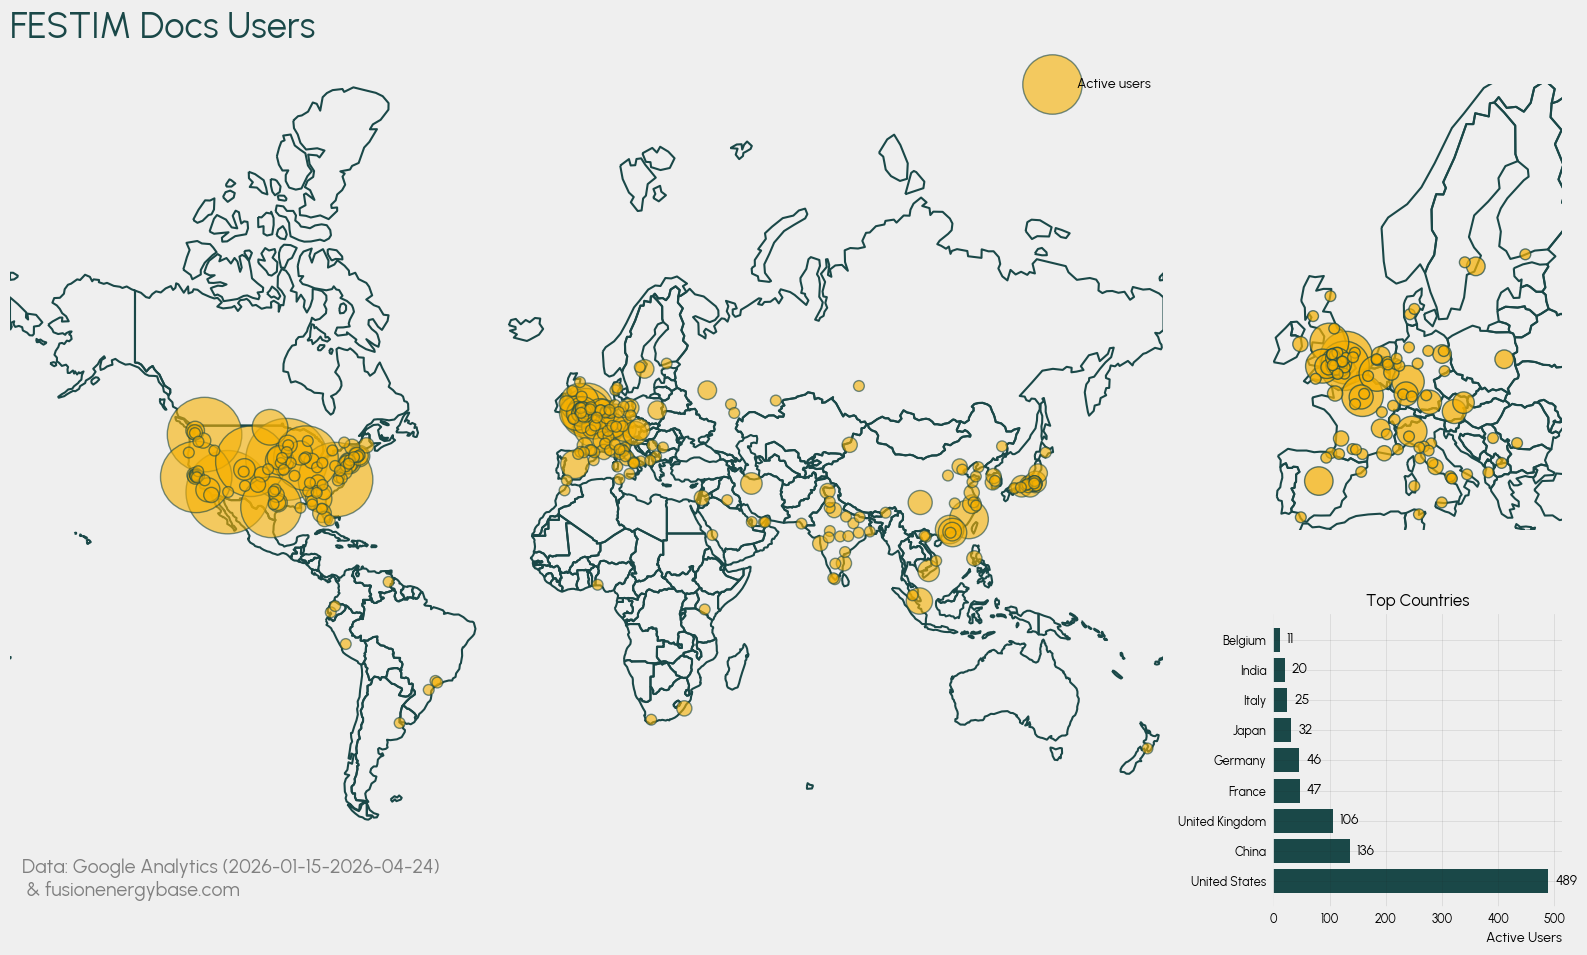

In [64]:
proj = ccrs.Mercator()

size_factor = 0.8
# Create figure and gridspec with 2x2 layout
fig = plt.figure(figsize=(20 * size_factor, 12 * size_factor))
gs = gridspec.GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[2, 1])

# Create map subplot (left side, spanning both rows) with cartopy projection
ax_map = fig.add_subplot(gs[:, 0], projection=proj)
ax_map.set_axis_off()

# background map
world.boundary.plot(ax=ax_map)

# transform the coordinates to the projection's CRS
pc = ccrs.PlateCarree()
new_coords = proj.transform_points(pc, locations_users.geometry.x, locations_users.geometry.y)

# change the colour of the border of the bubbles to c0 and the fill to c1

ax_map.scatter(
    new_coords[:, 0],
    new_coords[:, 1],
    s=df_users["activeUsers"] * 60,  # size of the bubbles
    # s=df['Average engagement time per active user'] * 0.3,  # size of the bubbles
    zorder=10,  # this specifies to put bubbles on top of the map
    alpha=0.6,
    color="C1",
    edgecolors="C0",
    linewidth=1,
    label="Active users"
)

# plot_locations(locations_fusion_developers, pc, color="tab:red", alpha=0.7, s=20, label="Fusion machine developers", zorder=11)
# plot_locations(locations_orgs, pc, color="tab:blue", alpha=0.7, s=20, label="Research Organizations", zorder=11)

plt.legend(frameon=False)


# Create Europe subplot (top right) with cartopy projection
ax_europe = fig.add_subplot(gs[0, 1], projection=proj)
ax_europe.set_axis_off()

# Plot Europe in the top right
plot_europe(ax_europe, s=df_users["activeUsers"] * 60, locations=locations_users)
# plot_locations(locations_fusion_developers, pc, color="tab:red", alpha=0.7, s=20, label="Fusion machine developers", zorder=11)
# plot_locations(locations_orgs, pc, color="tab:blue", alpha=0.7, s=20, label="Research Organizations", zorder=11)


# Create chart subplot (bottom right) - regular matplotlib subplot
ax_chart = fig.add_subplot(gs[1, 1])
countries = [row.dimension_values[0].value for row in response_countries.rows]
active_users = [int(row.metric_values[0].value) for row in response_countries.rows]
# new_users = [int(row.metric_values[1].value) for row in response_countries.rows]

# group others
top_countries = countries[:9]
top_active_users = active_users[:9]
# top_new_users = new_users[:10]

ax_chart.barh(top_countries, top_active_users, label="Active Users")

plt.bar_label(ax_chart.containers[0], fmt="%d", padding=5)
ax_chart.set_xlabel("Active Users")
ax_chart.set_title("Top Countries")

data_from = f"Data: Google Analytics ({start_date_ga.strftime('%Y-%m-%d')}-{datetime.today().strftime('%Y-%m-%d')})"
data_from += "\n & fusionenergybase.com"
ax_map.annotate(
    data_from,
    xy=(0.01, -0.05),
    xycoords="axes fraction",
    ha="left",
    fontsize=14,
    color="gray",
)
ax_map.set_title("FESTIM Docs Users", fontsize=26, fontweight="bold", loc="left", pad=20, color="C0")


plt.tight_layout()
plt.savefig("users_world_map.svg")
plt.show()

## Average engagement time per user

In [65]:
response = engagement_time_per_active_user(FESTIM_TUTO_ID)

Report result:
Cambridge 43433 30
(not set) 35377 97
Munich 12585 13
Kyoto 5968 5
Garching 5398 9
Thatcham 4154 2
Minneapolis 4061 3
Manchester 3888 10
London 3461 12
Madrid 3204 3
Saclay 2473 1
Boston 2378 9
Erkrath 2358 1
Julich 2161 2
Kansas City 2088 1
Chennai 1895 2
Shenzhen 1537 2
Everett 1460 2
Philadelphia 1413 1
Shanghai 1312 4
Naples 1276 1
Didcot 1132 2
Turin 1097 3
Stuttgart 953 1
Paris 951 9
Ningbo 878 1
Framingham 874 2
Tsukuba 868 2
Kearny 854 2
Chicago 819 6
New York 789 3
Frankfurt am Main 754 2
Pistoia 748 1
Madison 728 1
Murfreesboro 685 1
Hendersonville 633 1
 576 4
Somerville 569 5
Lohne 557 1
Milan 550 3
Dublin 545 4
Bristol 532 3
San Francisco 499 1
Coventry 480 1
Wessling 457 1
Knoxville 440 1
Coutances 429 1
Newark 427 3
Brighton 419 1
Escanaba 392 1
Hamburg 381 1
San Diego 344 3
Fall River 299 2
Washington 277 1
Dortmund 246 1
Arkadelphia 236 1
Mesick 236 1
Leoben 222 1
Dresden 199 1
Barranquilla 196 1
Hiroshima 195 1
Bangor 183 1
Canajoharie 170 1
Eindhoven 1

In [66]:
df_engagement = pd.DataFrame(
    {
        "city": [row.dimension_values[0].value for row in response.rows],
        "engagementTime": [int(row.metric_values[0].value) for row in response.rows],
        "activeUsers": [int(row.metric_values[1].value) for row in response.rows],
    }
)
df_engagement.head()

,city,engagementTime,activeUsers
0,Cambridge,43433,30
1,(not set),35377,97
2,Munich,12585,13
3,Kyoto,5968,5
4,Garching,5398,9


In [67]:
df_engagement["engagementTimePerActiveUser"] = df_engagement["engagementTime"] / df_engagement["activeUsers"]

# sort by engagementTimePerActiveUser
df_engagement = df_engagement.sort_values(by="engagementTimePerActiveUser", ascending=False)

df_engagement.head()

,city,engagementTime,activeUsers,engagementTimePerActiveUser
10,Saclay,2473,1,2473.000000
12,Erkrath,2358,1,2358.000000
14,Kansas City,2088,1,2088.000000
5,Thatcham,4154,2,2077.000000
0,Cambridge,43433,30,1447.766667


In [68]:
# try and find from cache first, if not found, geocode the city
if os.path.exists("locations_engagement.geojson"):
    locations_engagement_from_cache = gpd.read_file("locations_engagement.geojson")
    locations_engagement_not_found = set(df_engagement["city"]) - set(locations_engagement_from_cache["city"])
    if locations_engagement_not_found:
        print(f"Geocoding {len(locations_engagement_not_found)} cities for engagement...")
        locations_engagement_new = gpd.tools.geocode(list(locations_engagement_not_found))
        locations_engagement = pd.concat([locations_engagement_from_cache, locations_engagement_new], ignore_index=True)
    else:
        locations_engagement = locations_engagement_from_cache
else:
    print("Geocoding cities for engagement...")
    locations_engagement = gpd.tools.geocode(df_engagement["city"])

In [69]:
locations_engagement["city"] = df_engagement["city"]
locations_engagement.to_file("locations_engagement.geojson", driver="GeoJSON")

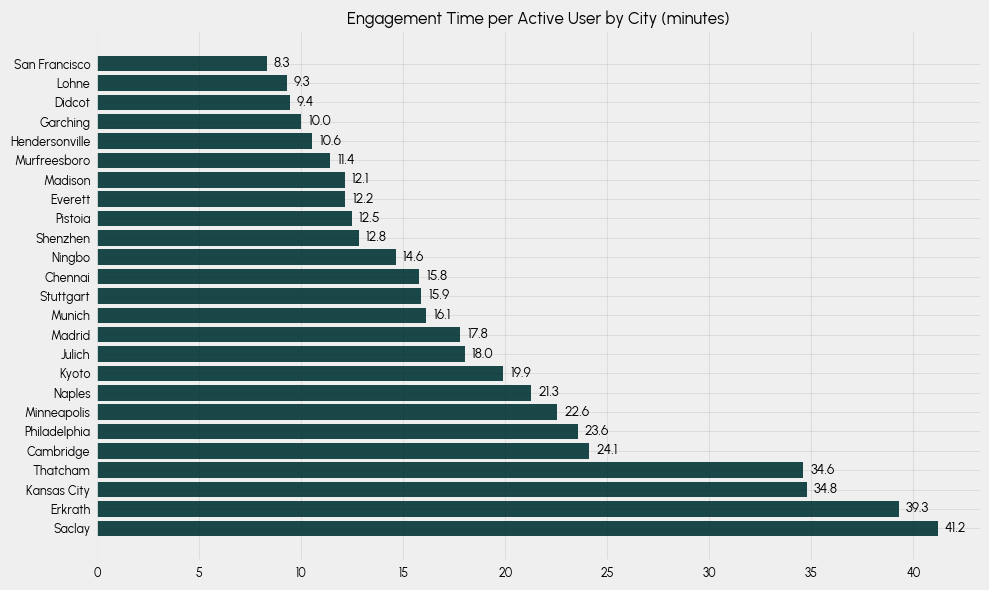

In [70]:
seconds_to_minutes = 1/60

slice_size = 25
df_engagement_slice = df_engagement.head(slice_size)
# remove (not set) from df_slice
df_engagement_slice = df_engagement_slice[df_engagement_slice['city'] != '(not set)']

plt.figure(figsize=(10, 6))
plt.barh(df_engagement_slice["city"], df_engagement_slice["engagementTimePerActiveUser"] * seconds_to_minutes)
plt.bar_label(plt.gca().containers[0], fmt="%.1f", padding=5)
plt.title("Engagement Time per Active User by City (minutes)")
plt.tight_layout()
plt.show()

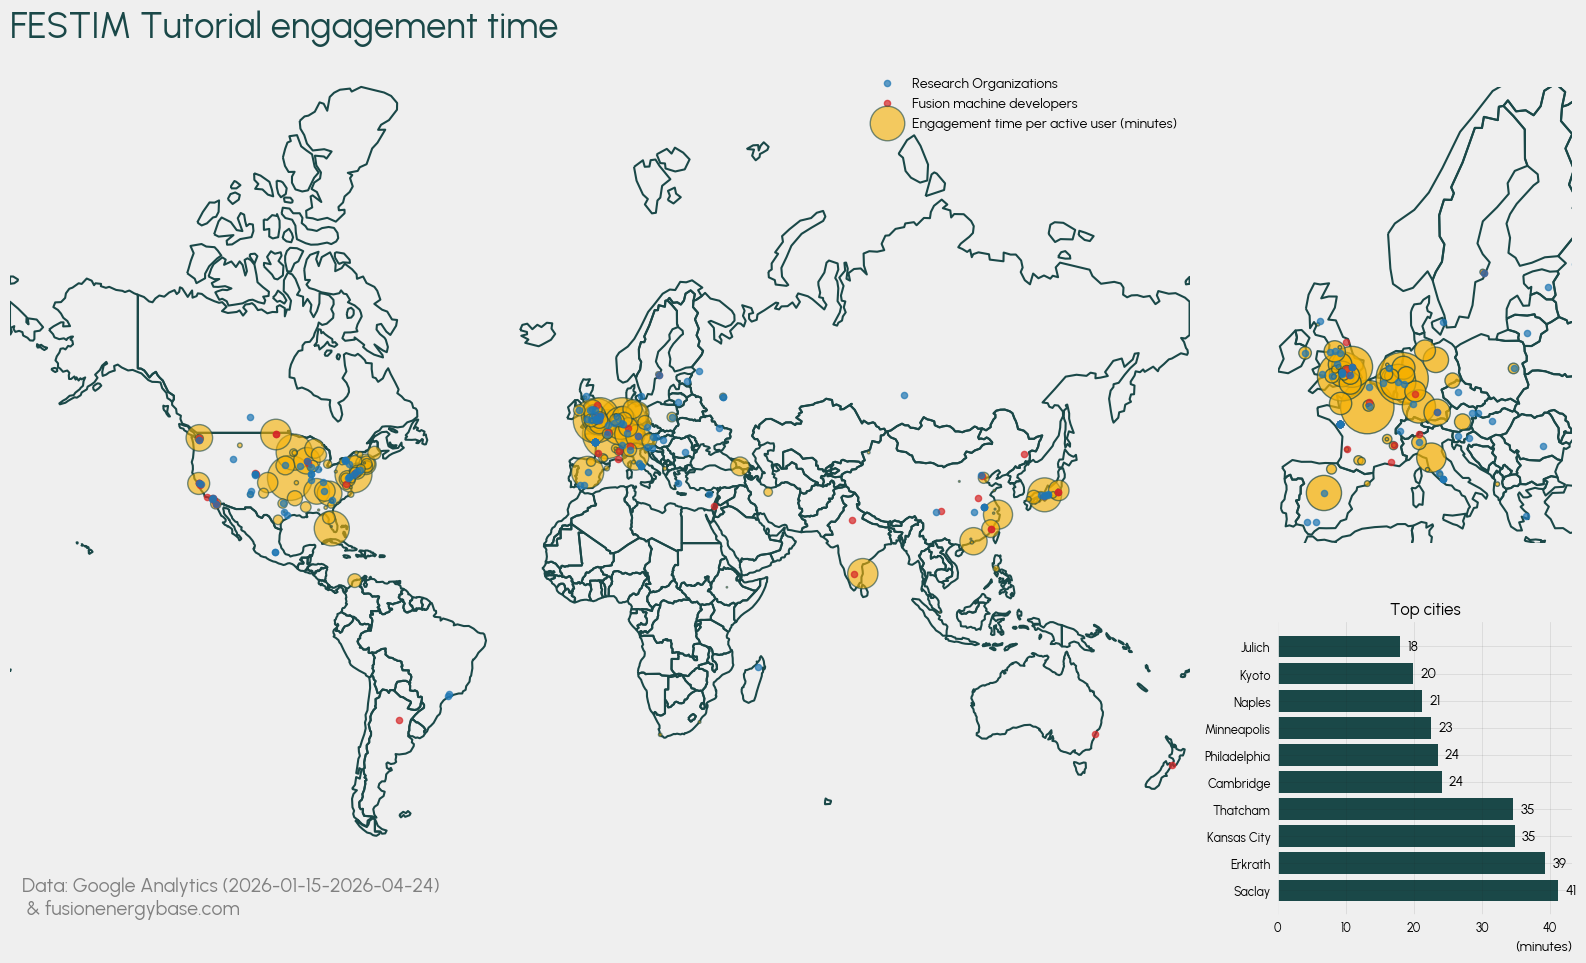

In [71]:
proj = ccrs.Mercator()

size_factor = 0.8
# Create figure and gridspec with 2x2 layout
fig = plt.figure(figsize=(20 * size_factor, 12 * size_factor))
gs = gridspec.GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[2, 1])

# Create map subplot (left side, spanning both rows) with cartopy projection
ax_map = fig.add_subplot(gs[:, 0], projection=proj)
ax_map.set_axis_off()

# background map
world.boundary.plot(ax=ax_map)

# transform the coordinates to the projection's CRS
pc = ccrs.PlateCarree()
new_coords_engagement = proj.transform_points(pc, locations_engagement.geometry.x, locations_engagement.geometry.y)

# change the colour of the border of the bubbles to c0 and the fill to c1
ax_map.scatter(
    new_coords_engagement[:, 0],
    new_coords_engagement[:, 1],
    s=df_engagement["engagementTimePerActiveUser"] * 0.5,  # size of the bubbles
    # s=df['Average engagement time per active user'] * 0.3,  # size of the bubbles
    zorder=10,  # this specifies to put bubbles on top of the map
    alpha=0.6,
    color="C1",
    edgecolors="C0",
    linewidth=1,
    label="Engagement time per active user (minutes)"
)
plot_locations(locations_fusion_developers, pc, color="tab:red", alpha=0.7, s=20, label="Fusion machine developers", zorder=11)
plot_locations(locations_orgs, pc, color="tab:blue", alpha=0.7, s=20, label="Research Organizations", zorder=11)

plt.legend(frameon=False, reverse=True)

# Create Europe subplot (top right) with cartopy projection
ax_europe = fig.add_subplot(gs[0, 1], projection=proj)
ax_europe.set_axis_off()

# Plot Europe in the top right
nb_days = (datetime.today() - start_date_ga).days
plot_europe(ax_europe, s=df_engagement["engagementTimePerActiveUser"] * 0.6, locations=locations_engagement)
plot_locations(locations_fusion_developers, pc, color="tab:red", alpha=0.7, s=20, label="Fusion machine developers", zorder=11)
plot_locations(locations_orgs, pc, color="tab:blue", alpha=0.7, s=20, label="Research Organizations", zorder=11)

# Create chart subplot (bottom right) - regular matplotlib subplot
ax_chart = fig.add_subplot(gs[1, 1])
new_slice = df_engagement_slice.head(10)
ax_chart.barh(
    new_slice["city"],
    new_slice["engagementTimePerActiveUser"] * seconds_to_minutes,
    label="Engagement Time per Active User (minutes)",
)

plt.bar_label(ax_chart.containers[0], fmt="%.0f", padding=5)
ax_chart.set_title("Top cities")
ax_chart.set_xlabel("(minutes)")

data_from = f"Data: Google Analytics ({start_date_ga.strftime('%Y-%m-%d')}-{datetime.today().strftime('%Y-%m-%d')})"
data_from += "\n & fusionenergybase.com"
ax_map.annotate(
    data_from,
    xy=(0.01, -0.05),
    xycoords="axes fraction",
    ha="left",
    fontsize=14,
    color="gray",
)

ax_map.set_title(
    "FESTIM Tutorial engagement time",
    fontsize=26,
    fontweight="bold",
    loc="left",
    pad=20,
    color="C0",
)
plt.tight_layout()
plt.savefig("users_world_map.svg")
plt.show()